In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from glob import glob
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import wandb
import joblib
import torchvision.transforms as transforms
from torchvision.transforms import v2

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import timm
import matplotlib.pyplot as plt

from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
gt_path = 'train_gt.csv'
wavelength_path = 'wavelengths.csv'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

output_dir = '/content/test_data'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

!tar -xzvf /content/drive/MyDrive/test.tar.gz -C {output_dir}

test/
test/77.npz
test/837.npz
test/189.npz
test/63.npz
test/823.npz
test/638.npz
test/610.npz
test/88.npz
test/176.npz
test/162.npz
test/604.npz
test/1145.npz
test/1151.npz
test/348.npz
test/374.npz
test/412.npz
test/406.npz
test/360.npz
test/599.npz
test/1019.npz
test/1031.npz
test/1025.npz
test/228.npz
test/200.npz
test/566.npz
test/572.npz
test/214.npz
test/943.npz
test/957.npz
test/758.npz
test/980.npz
test/994.npz
test/764.npz
test/770.npz
test/771.npz
test/765.npz
test/995.npz
test/981.npz
test/759.npz
test/956.npz
test/942.npz
test/573.npz
test/215.npz
test/201.npz
test/567.npz
test/229.npz
test/1024.npz
test/1030.npz
test/1018.npz
test/598.npz
test/407.npz
test/361.npz
test/375.npz
test/413.npz
test/349.npz
test/1150.npz
test/1144.npz
test/163.npz
test/605.npz
test/89.npz
test/611.npz
test/177.npz
test/639.npz
test/822.npz
test/62.npz
test/836.npz
test/76.npz
test/188.npz
test/60.npz
test/820.npz
test/74.npz
test/834.npz
test/48.npz
test/808.npz
test/149.npz
test/607.npz
test/

In [ ]:
output_dir = '/content/train_data'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

!tar -xzvf /content/drive/MyDrive/train.tar.gz -C {output_dir}

train/
train/77.npz
train/837.npz
train/189.npz
train/1409.npz
train/63.npz
train/823.npz
train/1347.npz
train/1421.npz
train/1435.npz
train/1353.npz
train/638.npz
train/610.npz
train/1384.npz
train/88.npz
train/176.npz
train/162.npz
train/1390.npz
train/604.npz
train/1179.npz
train/1623.npz
train/1145.npz
train/1151.npz
train/1637.npz
train/348.npz
train/374.npz
train/1186.npz
train/412.npz
train/406.npz
train/1192.npz
train/360.npz
train/599.npz
train/1019.npz
train/1031.npz
train/1025.npz
train/228.npz
train/200.npz
train/566.npz
train/572.npz
train/214.npz
train/943.npz
train/1569.npz
train/957.npz
train/1233.npz
train/1555.npz
train/1541.npz
train/1227.npz
train/758.npz
train/980.npz
train/994.npz
train/764.npz
train/1596.npz
train/1582.npz
train/770.npz
train/1583.npz
train/771.npz
train/765.npz
train/1597.npz
train/995.npz
train/981.npz
train/759.npz
train/1540.npz
train/1226.npz
train/1232.npz
train/1554.npz
train/956.npz
train/942.npz
train/1568.npz
train/573.npz
train/215.npz

In [ ]:
gt_df = pd.read_csv(gt_path)
wavelength_df = pd.read_csv(wavelength_path)

In [ ]:
# def load_data(directory: str):
#     data = []

#     all_files = np.array(
#         sorted(
#             glob(os.path.join(directory, "*.npz")),
#             key=lambda x: int(os.path.basename(x).replace(".npz", "")),
#         )
#     )

#     for file_name in all_files:
#         with np.load(file_name) as npz:
#             raw_arr = np.ma.MaskedArray(data=npz['data'], mask=npz['mask'])
#             img_tensor_raw = torch.as_tensor(raw_arr.data, dtype=torch.float)
#             img_tensor_mask = ~torch.as_tensor(raw_arr.mask) # Revert mask: 0 is invalid, 1 is valid
#             img_tensor_masked = torch.mul(img_tensor_raw, img_tensor_mask)
#         data.append(img_tensor_masked)

#     return data

In [ ]:
def load_data(directory: str):
    data = []

    all_files = np.array(
        sorted(
            glob(os.path.join(directory, "*.npz")),
            key=lambda x: int(os.path.basename(x).replace(".npz", "")),
        )
    )

    for file_name in all_files:
        with np.load(file_name) as npz:
            # Create masked array
            raw_arr = np.ma.MaskedArray(
                data=npz['data'],
                mask=npz['mask']
            )

            # Raw tensor (KEEP values as-is)
            img_tensor = torch.as_tensor(raw_arr.data, dtype=torch.float32)

            # Mask: 1 = valid, 0 = invalid
            mask = ~torch.as_tensor(raw_arr.mask)

        # Store BOTH
        data.append((img_tensor, mask))

    return data

In [ ]:
def load_gt(file_path: str):
    """Load labels for train set from the ground truth file.
    Args:
        file_path (str): Path to the ground truth .csv file.
    Returns:
        [type]: 2D numpy array with soil properties levels
    """
    gt_file = pd.read_csv(file_path)
    labels = gt_file[["P", "K", "Mg", "pH"]].values
    return labels

In [ ]:
X_train_full_data = load_data("/content/train_data/train")
y_train = load_gt("train_gt.csv")

In [ ]:
original_spectral_channels = X_train_full_data[0][0].shape[0]
print(f"Original spectral channels: {original_spectral_channels}")
reduced_spectral_channels = 3 # Number of channels after 1x1 convolution

Original spectral channels: 150


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

# -----------------------
# Split into train, val, test
# -----------------------

# Create an array of indices for X_train_full_data
original_indices = np.arange(len(X_train_full_data))

# First, split off test set (20%)
X_temp, X_test, y_temp, y_test, temp_indices, test_indices = train_test_split(
    X_train_full_data, y_train, original_indices, test_size=0.2, random_state=93
)

# Then, split remaining 80% into train/val (20% val of original, means 25% of X_temp)
X_train_final, X_val, y_train_final, y_val, train_indices, val_indices = train_test_split(
    X_temp, y_temp, temp_indices, test_size=0.25, random_state=93
)

print(f"Train patches: {len(X_train_final)}")
print(f"Validation patches: {len(X_val)}")
print(f"Test patches: {len(X_test)}")

Train patches: 1038
Validation patches: 347
Test patches: 347


In [ ]:
def _pad_to_size_static(x, mask, size=(224, 224)):
    _, h, w = x.shape
    th, tw = size

    # ---- STEP 1: CROP if too large ----
    if h > th:
        start_h = (h - th) // 2
        x = x[:, start_h:start_h + th, :]
        mask = mask[:, start_h:start_h + th, :]
        h = th

    if w > tw:
        start_w = (w - tw) // 2
        x = x[:, :, start_w:start_w + tw]
        mask = mask[:, :, start_w:start_w + tw]
        w = tw

    # ---- STEP 2: PAD if too small ----
    pad_h = th - h
    pad_w = tw - w

    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top
    pad_left = pad_w // 2
    pad_right = pad_w - pad_left

    x = F.pad(x, (pad_left, pad_right, pad_top, pad_bottom), value=0)
    mask = F.pad(mask, (pad_left, pad_right, pad_top, pad_bottom), value=0)

    return x, mask

def calculate_global_stats(X_data, pad_function):
    print("Calculating global per-channel means and std deviations from training data...")

    # Initialize lists to store valid pixel values for each channel
    num_channels = X_data[0][0].shape[0]
    channel_data = [[] for _ in range(num_channels)]

    for x_item, mask_item in tqdm(X_data, desc="Processing X_data for global stats"):
        # Pad to consistent size first, as this affects the mask and values
        x_padded, mask_padded = pad_function(x_item, mask_item)

        # Extract valid pixels per channel
        for c in range(num_channels):
            valid_c_pixels = x_padded[c][mask_padded[c]].cpu().numpy()
            channel_data[c].extend(valid_c_pixels)

    # Calculate global mean and std for each channel
    global_means = torch.tensor([np.mean(c_data) for c_data in channel_data], dtype=torch.float32)
    global_stds = torch.tensor([np.std(c_data) for c_data in channel_data], dtype=torch.float32)

    print(f"Global Means (per channel): {global_means}")
    print(f"Global Std Devs (per channel): {global_stds}")
    return global_means, global_stds

# Call the new function to calculate global_means and global_stds
global_means, global_stds = calculate_global_stats(X_train_final, _pad_to_size_static)


Calculating global per-channel means and std deviations from training data...


Processing X_data for global stats: 100%|██████████| 1038/1038 [00:58<00:00, 17.72it/s]


Global Means (per channel): tensor([ 335.9208,  335.9069,  331.7341,  338.8154,  347.5788,  364.8742,
         374.7284,  375.6686,  377.9044,  380.5071,  385.3977,  393.0356,
         398.9632,  414.6352,  429.2801,  437.0627,  446.8707,  456.7486,
         466.4856,  467.3013,  475.4815,  490.8455,  513.5848,  538.7640,
         552.9874,  561.9896,  574.5370,  582.4282,  594.5684,  603.2874,
         615.0793,  623.9404,  630.4449,  633.6147,  633.7065,  634.5967,
         641.4842,  646.1486,  654.0912,  663.0143,  672.3674,  677.5461,
         681.8059,  684.6404,  691.3089,  698.3139,  701.8467,  701.3326,
         704.2673,  707.9794,  713.8121,  717.9084,  720.1819,  720.1807,
         724.6096,  729.8087,  735.5328,  749.8523,  756.5817,  753.4753,
         745.9611,  736.2238,  730.0534,  727.6396,  731.4945,  725.1307,
         721.3279,  725.2855,  735.6935,  767.1006,  809.9006,  859.7301,
         909.7721,  953.6044,  989.5249, 1022.1210, 1063.2218, 1101.7101,
        11

In [ ]:
global_means.shape

torch.Size([150])

In [ ]:
global_stds.shape

torch.Size([150])

In [ ]:
# -------------------------------
# Scale labels
# -------------------------------
scaler_y = StandardScaler()
y_train_final_scaled = scaler_y.fit_transform(y_train_final)
y_val_scaled   = scaler_y.transform(y_val)
y_test_scaled  = scaler_y.transform(y_test)
joblib.dump(scaler_y, "scaler_labels.pkl")
print("Label scaler saved.")

Label scaler saved.


In [ ]:
import torch
from torch.utils.data import Dataset
import torch.nn.functional as F
from torchvision.transforms import v2


class NPZDataset(Dataset):
    def __init__(self, tensor_list, labels = None, augment=True, size=(224, 224), global_means=None, global_stds=None):
        """
        tensor_list: list of tuples -> [(x, mask), ...]
                     x: (C, H, W)
                     mask: (C, H, W) with 1=valid, 0=invalid
        """
        self.tensor_list = tensor_list
        self.labels = labels
        self.augment = augment
        self.size = size
        self.global_means = global_means
        self.global_stds = global_stds

        self.transform_aug = v2.Compose([
            v2.RandomHorizontalFlip(p=0.5),
            v2.GaussianNoise(mean=0.0, sigma=0.03),
        ])

        #self.transform_basic = v2.Compose([])

    def __len__(self):
        return len(self.tensor_list)

    # ┅ Crop (if too large) + Pad (if too small)
    def pad_to_size(self, x, mask):
        _, h, w = x.shape
        th, tw = self.size

        # ---- STEP 1: CROP if too large ----
        if h > th:
            start_h = (h - th) // 2
            x = x[:, start_h:start_h + th, :]
            mask = mask[:, start_h:start_h + th, :]
            h = th

        if w > tw:
            start_w = (w - tw) // 2
            x = x[:, :, start_w:start_w + tw]
            mask = mask[:, :, start_w:start_w + tw]
            w = tw

        # ---- STEP 2: PAD if too small ----
        pad_h = th - h
        pad_w = tw - w

        pad_top = pad_h // 2
        pad_bottom = pad_h - pad_top
        pad_left = pad_w // 2
        pad_right = pad_w - pad_left

        x = F.pad(x, (pad_left, pad_right, pad_top, pad_bottom), value=0)
        mask = F.pad(mask, (pad_left, pad_right, pad_top, pad_bottom), value=0)

        return x, mask

    def normalize_with_mask(self, x, mask):
        # mask: 1 = valid, 0 = invalid
        if self.global_means is not None and self.global_stds is not None:
            # Use global per-channel statistics for normalization
            # Reshape global_means and global_stds to (C, 1, 1) for broadcasting
            x_norm = (x - self.global_means.to(x.device).view(-1, 1, 1)) / \
                     (self.global_stds.to(x.device).view(-1, 1, 1) + 1e-6)

        # ---- IMPORTANT: keep invalid pixels neutral ----
        x_norm = x_norm * mask

        return x_norm

    def __getitem__(self, idx):
        x, mask = self.tensor_list[idx]

        # 1. FIX SIZE FIRST
        x, mask = self.pad_to_size(x, mask)

        # 2. NORMALIZE USING MASK
        x = self.normalize_with_mask(x, mask)

        # 4. AUGMENTATION (only if labels are present, typically for training/validation)
        if self.augment and self.labels is not None:
            x = self.transform_aug(x)

        if self.labels is not None:
            y = torch.tensor(self.labels[idx], dtype=torch.float32)
            return x, y
        else:
            # For submission or inference without labels, return only the features
            return x


In [ ]:
def check_normalized_stats(dataset: NPZDataset, device: torch.device):
    """
    Checks the per-channel mean and standard deviation of data AFTER normalization.
    It re-applies padding and normalization from the dataset's methods to raw data
    and then calculates statistics only on valid (non-masked) normalized pixels.
    """
    print("\nChecking per-channel means and std deviations for normalized data...")

    num_channels = dataset.tensor_list[0][0].shape[0]
    channel_data_normalized = [[] for _ in range(num_channels)]

    for idx in tqdm(range(len(dataset)), desc="Processing dataset for normalized stats"): # Iterate through the original data for accurate stats
        x_raw, mask_raw = dataset.tensor_list[idx]

        # Apply padding using the dataset's method
        x_padded, mask_padded = dataset.pad_to_size(x_raw, mask_raw)

        # Apply normalization using the dataset's method (which uses global_means/stds)
        x_normalized = dataset.normalize_with_mask(x_padded, mask_padded)

        # Extract valid pixels per channel from the normalized data
        for c in range(num_channels):
            # Ensure mask_padded is also on CPU if x_normalized is on CPU for indexing
            valid_c_pixels = x_normalized[c][mask_padded[c]].cpu().numpy()
            channel_data_normalized[c].extend(valid_c_pixels)

    # Calculate mean and std for each channel from the normalized valid pixels
    means_normalized = torch.tensor([np.mean(c_data) for c_data in channel_data_normalized if len(c_data) > 0], dtype=torch.float32)
    stds_normalized = torch.tensor([np.std(c_data) for c_data in channel_data_normalized if len(c_data) > 0], dtype=torch.float32)

    print(f"Normalized Means (per channel): {means_normalized}")
    print(f"Normalized Std Devs (per channel): {stds_normalized}")
    return means_normalized, stds_normalized

In [ ]:
# -----------------------
# Create Dataset and DataLoader with global stats
# -----------------------

train_dataset = NPZDataset(X_train_final, y_train_final_scaled, augment=True, global_means=global_means, global_stds=global_stds)
val_dataset   = NPZDataset(X_val, y_val_scaled, augment=False, global_means=global_means, global_stds=global_stds)
test_dataset  = NPZDataset(X_test, y_test_scaled, augment=False, global_means=global_means, global_stds=global_stds)


train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)


In [ ]:
# Verify normalization for the training dataset
normalized_means_train, normalized_stds_train = check_normalized_stats(train_dataset, device)


Checking per-channel means and std deviations for normalized data...


Processing dataset for normalized stats: 100%|██████████| 1038/1038 [00:56<00:00, 18.45it/s]


In [ ]:
import torch
import torch.nn as nn
import timm

class HyperspectralRegressor(nn.Module):
    def __init__(
        self,
        original_in_channels: int = 150,
        reduced_in_channels: int = 10,
        n_outputs: int = 4,
        backbone_name: str = "efficientnet_b0",
        pretrained: bool = False,
        dropout: float = 0.3,
        regressor: nn.Module = None,
    ):
        """
        original_in_channels: Number of input spectral bands (masked pixels are zero).
        reduced_in_channels: Number of channels after 1x1 convolution.
        n_outputs: Number of regression outputs.
        backbone_name: Name of the model in timm.
        pretrained: Whether to load ImageNet weights (safe only if reduced_in_channels==3).
        """
        super().__init__()

        # 1x1 spectral reducer: Conv -> BN -> ReLU
        self.spectral_reducer = nn.Sequential(
            nn.Conv2d(original_in_channels, reduced_in_channels, kernel_size=1, bias=True),
            nn.BatchNorm2d(reduced_in_channels),
            nn.ReLU(inplace=True),
        )

        effective_pretrained = pretrained
        if pretrained and reduced_in_channels != 3:
            effective_pretrained = False

        self.backbone = timm.create_model(
            backbone_name,
            pretrained=effective_pretrained,
            in_chans=reduced_in_channels,
            num_classes=0,
        )

        feat_dim = getattr(self.backbone, "num_features", None)
        if feat_dim is None:
            if hasattr(self.backbone, "fc") and hasattr(self.backbone.fc, "in_features"):
                feat_dim = self.backbone.fc.in_features
            else:
                raise RuntimeError("Backbone features cannot be determined")

        # Use provided regressor or default to the original one
        if regressor is None:
            self.regressor = nn.Sequential(
                nn.Linear(feat_dim, 512),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout),
                nn.Linear(512, n_outputs),
            )
        else:
            self.regressor = regressor

        nn.init.kaiming_normal_(self.spectral_reducer[0].weight, nonlinearity="relu")
        if self.spectral_reducer[0].bias is not None:
            nn.init.zeros_(self.spectral_reducer[0].bias)

    def forward(self, x):
        """
        x: (B, original_in_channels, H, W)  -- masked pixels = 0
        returns: (B, n_outputs)
        """
        x = self.spectral_reducer(x)      # (B, reduced_in_channels, H, W)
        features = self.backbone(x)       # (B, feat_dim)
        out = self.regressor(features)    # (B, n_outputs)
        return out

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True


## **Overfitting on one batch**

In [ ]:
def overfit_single_batch(
    model: nn.Module,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    x_single: torch.Tensor,
    y_single: torch.Tensor,
    epochs: int = 500,
    device: torch.device = torch.device("cpu")
):
    """
    Performs overfitting of a model on a single batch of data.

    Args:
        model (nn.Module): The model to overfit.
        criterion (nn.Module): The loss function.
        optimizer (optim.Optimizer): The optimizer.
        x_single (torch.Tensor): The input features for the single batch.
        y_single (torch.Tensor): The target labels for the single batch.
        epochs (int): The number of epochs to train for.
        device (torch.device): The device (CPU/GPU) to run the training on.
    """
    print(f"\n--- Starting Overfitting on Single Batch for {epochs} epochs ---")

    x_single, y_single = x_single.to(device), y_single.to(device)

    for epoch_overfit in range(epochs):
        model.train()
        optimizer.zero_grad()

        outputs_overfit = model(x_single)
        loss_overfit = criterion(outputs_overfit, y_single)

        loss_overfit.backward()
        optimizer.step()

        if (epoch_overfit + 1) % 10 == 0 or epoch_overfit == 0:
            print(f"Overfit Epoch {epoch_overfit+1}/{epochs} - Loss: {loss_overfit.item():.6f}")

    print("--- Overfitting complete ---")

In [ ]:
train_data_single_batch = next(iter(train_loader))

In [ ]:
train_data_single_batch[0].shape

torch.Size([64, 150, 224, 224])

In [ ]:
train_data_single_batch[1].shape

torch.Size([64, 4])

In [ ]:
import torch
import torch.nn as nn
import timm

# Re-initialize a fresh model for overfitting
model_overfit = HyperspectralRegressor(
    reduced_in_channels = 3,   # reduced channels
    n_outputs = 4,      # P, K, Mg, pH
    backbone_name = "convnext_base_in22k",
    pretrained = True  # Use pre-trained weights
)
model_overfit = model_overfit.to(device)

# Define optimizer and criterion for overfitting
optimizer_overfit = optim.AdamW(model_overfit.parameters(), lr=8e-5, weight_decay=1e-4)
criterion_overfit = nn.SmoothL1Loss(beta=1.0)

# Extract the single batch
x_single, y_single = train_data_single_batch

# Move x_single and y_single to the device for consistent usage
x_single = x_single.to(device)
y_single = y_single.to(device)

# Call the overfit_single_batch function
overfit_single_batch(
    model=model_overfit,
    criterion=criterion_overfit,
    optimizer=optimizer_overfit,
    x_single=x_single,
    y_single=y_single,
    epochs=100,
    device=device
)

/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name convnext_base_in22k to current convnext_base.fb_in22k.
  model = create_fn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]


--- Starting Overfitting on Single Batch for 100 epochs ---
Overfit Epoch 1/100 - Loss: 0.450368
Overfit Epoch 10/100 - Loss: 0.241486
Overfit Epoch 20/100 - Loss: 0.069687
Overfit Epoch 30/100 - Loss: 0.021556
Overfit Epoch 40/100 - Loss: 0.017770
Overfit Epoch 50/100 - Loss: 0.015186
Overfit Epoch 60/100 - Loss: 0.013060
Overfit Epoch 70/100 - Loss: 0.014344
Overfit Epoch 80/100 - Loss: 0.009942
Overfit Epoch 90/100 - Loss: 0.011951
Overfit Epoch 100/100 - Loss: 0.012068
--- Overfitting complete ---


In [ ]:
print('\n--- Model Overfit Predictions vs. True Values ---')
model_overfit.eval() # Set model to evaluation mode

with torch.no_grad():
    outputs_single_batch = model_overfit(x_single)

print("Predictions:")
print(outputs_single_batch.cpu().numpy())
print("\nTrue Values:")
print(y_single.cpu().numpy())


--- Model Overfit Predictions vs. True Values ---
Predictions:
[[-0.49326852  0.42544964  1.3154963  -1.5591632 ]
 [-1.3326854   0.8424472   1.6836411   0.5562009 ]
 [-0.8033349   0.6021602   0.28541684  0.08406287]
 [-0.6916579  -0.15126894 -1.7309012  -1.0819119 ]
 [-0.65845644 -0.84430206  1.1219705  -1.8029302 ]
 [-0.4718208   0.153808   -0.22064495  0.29844546]
 [ 0.59174436 -0.5876257  -0.31603894  0.4826819 ]
 [-0.46627045 -0.6789033  -0.5017163  -0.6529521 ]
 [ 0.12115322 -0.21493419 -0.09127805  0.4757113 ]
 [ 1.1137576   2.3602264  -0.08124782  2.211998  ]
 [ 0.5961181   0.2929509  -1.1817037   0.07345161]
 [-0.11377377 -0.2684372  -0.13895153 -1.0474842 ]
 [ 1.6637022   0.7477354   1.4042246   0.09545218]
 [-0.47917655 -0.91356415  0.85278994  0.4049458 ]
 [ 0.4160859   0.1462563   0.358995    0.03518713]
 [-1.1235795  -0.60380304 -1.8690336  -0.44044957]
 [ 1.0260412   1.3576623  -0.14420179  0.73257965]
 [ 2.5430446   3.527835    3.8068047   1.6862494 ]
 [ 0.26178923 -0.3

In [ ]:
# Load the label scaler
scaler_y = joblib.load("scaler_labels.pkl")
print("Label scaler loaded.")

print('\n--- Unscaled Model Overfit Predictions vs. Unscaled True Values ---')
# Inverse transform predictions and true values
unscaled_predictions = scaler_y.inverse_transform(outputs_single_batch.cpu().numpy())
unscaled_true_values = scaler_y.inverse_transform(y_single.cpu().numpy())

print("Unscaled Predictions:")
print(unscaled_predictions)
print("\nUnscaled True Values:")
print(unscaled_true_values)

Label scaler loaded.

--- Unscaled Model Overfit Predictions vs. Unscaled True Values ---
Unscaled Predictions:
[[ 56.243183  253.8624    210.44043     6.385297 ]
 [ 32.21387   278.9456    224.96335     6.9269195]
 [ 47.36716   264.49188   169.80487     6.806032 ]
 [ 50.56405   219.17169    90.26324     6.5074935]
 [ 51.51448   177.48447   202.80603     6.322882 ]
 [ 56.85715   237.52264   149.84126     6.8609233]
 [ 87.30297   192.92403   146.07806     6.908096 ]
 [ 57.016037  187.4335    138.7533      6.6173253]
 [ 73.83174   215.34212   154.94464     6.906311 ]
 [102.24622   370.24286   155.34033     7.350874 ]
 [ 87.42818   245.89235   111.928505    6.803315 ]
 [ 67.106674  212.12381   153.06398     6.5163083]
 [117.98905   273.2485    213.94066     6.8089485]
 [ 56.646584  173.31822   192.18713     6.888192 ]
 [ 82.27454   237.0684    172.70744     6.793518 ]
 [ 38.199776  191.95093    84.81406     6.671735 ]
 [ 99.73524   309.93674   152.85686     6.97208  ]
 [143.16127   440.476

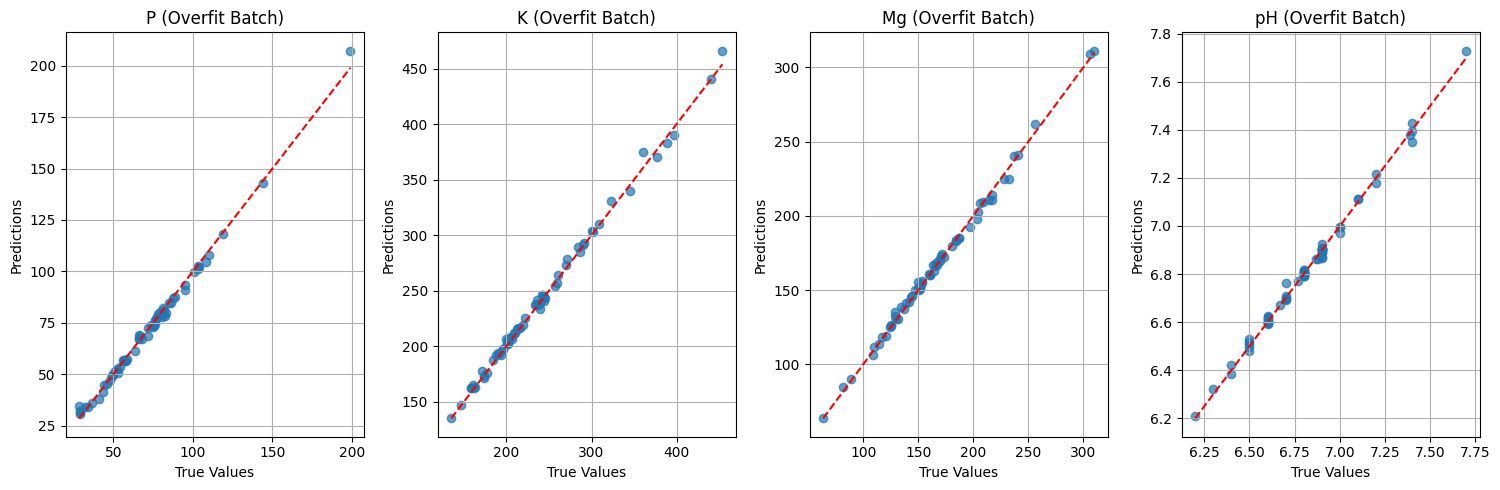

In [ ]:

plt.figure(figsize=(15, 5))

metrics = ['P', 'K', 'Mg', 'pH']
for i, metric in enumerate(metrics):
    plt.subplot(1, 4, i + 1) # 1 row, 4 columns
    plt.scatter(unscaled_true_values[:, i], unscaled_predictions[:, i], alpha=0.7)
    plt.plot([min(unscaled_true_values[:, i]), max(unscaled_true_values[:, i])],
             [min(unscaled_true_values[:, i]), max(unscaled_true_values[:, i])],
             'r--') # Red dashed line for ideal prediction
    plt.title(f'{metric} (Overfit Batch)')
    plt.xlabel('True Values')
    plt.ylabel('Predictions')
    plt.grid(True)

plt.tight_layout()
plt.show()


# **Training loop**

In [ ]:
import os
import torch
from tqdm import tqdm

def train_with_early_stopping(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,            # ReduceLROnPlateau expected
    criterion,
    device,
    epochs=120,
    warmup_epochs=5,
    patience=20,
    save_path="best_hyperspectral_model.pth",
    use_amp=True, # Re-introduced use_amp parameter
    max_grad_norm=1.0,
    wandb_run=None
):
    # initial LRs per param_group (order must match how optimizer was created)
    initial_lrs = [pg['lr'] for pg in optimizer.param_groups]

    best_val_loss = float('inf')
    early_stop_counter = 0
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp) # Re-introduced GradScaler initialization

    for epoch in range(epochs):
        # ---------- TRAIN ----------
        model.train()
        train_running_loss = 0.0
        train_samples = 0

        # linear warmup
        if epoch < warmup_epochs:
            warmup_factor = (epoch + 1) / float(warmup_epochs)
            for i, pg in enumerate(optimizer.param_groups):
                pg['lr'] = initial_lrs[i] * warmup_factor

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        for xb, yb in loop:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast(enabled=use_amp): # Re-introduced torch.cuda.amp.autocast context
                preds = model(xb)
                loss = criterion(preds, yb)

            scaler.scale(loss).backward() # Re-introduced scaler.scale and backward

            # Calculate gradient norm before clipping
            # Unscale the gradients before clipping, if using AMP
            if use_amp:
                scaler.unscale_(optimizer)

            # Pass inf to just calculate norm, not clip
            #total_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), float('inf'))
            total_norm = torch.sqrt(
                sum(p.grad.detach().norm(2)**2 for p in model.parameters() if p.grad is not None)
            )

            # for name, p in model.named_parameters():
            #   if p.grad is not None:
            #       print(name, p.grad.abs().mean().item())
            #       break

            # Clip gradient
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

            scaler.step(optimizer) # Re-introduced scaler.step
            scaler.update() # Re-introduced scaler.update

            bsz = xb.size(0)
            train_running_loss += loss.item() * bsz
            train_samples += bsz

            loop.set_postfix(
                train_loss=loss.item(),
                grad_norm=total_norm.item(), # Log gradient norm
                lr_backbone=optimizer.param_groups[0]['lr'],
                lr_head=optimizer.param_groups[1]['lr']
            )

        train_loss = train_running_loss / max(1, train_samples)

        # ---------- VALIDATION ----------
        model.eval()
        val_running_loss = 0.0
        val_samples = 0
        # optional threshold for logging outlier batches (set after first epoch if desired)
        outlier_threshold = None

        with torch.no_grad():
            for i, (xv, yv) in enumerate(val_loader):
                xv = xv.to(device, non_blocking=True)
                yv = yv.to(device, non_blocking=True)

                with torch.cuda.amp.autocast(enabled=use_amp): # Re-introduced torch.cuda.amp.autocast context
                    vpreds = model(xv)
                    vloss = criterion(vpreds, yv)

                bsz = xv.size(0)
                val_running_loss += vloss.item() * bsz
                val_samples += bsz

                # detect very large batch losses for debugging
                if outlier_threshold is not None and vloss.item() > outlier_threshold:
                    print(f"[DEBUG] Large val batch loss epoch {epoch+1} batch {i}: {vloss.item():.4f}")
                    # optionally save xv, yv, vpreds.cpu() for inspection

        val_loss = val_running_loss / max(1, val_samples)

        # ---------- SCHEDULER ----------
        # ReduceLROnPlateau expects scheduler.step(metric)
        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_loss)
        else:
            # if you use other schedulers, call scheduler.step() here (after warmup if needed)
            if epoch >= warmup_epochs - 1:
                scheduler.step()

        # ---------- LOGGING ----------
        current_lrs = [pg['lr'] for pg in optimizer.param_groups]
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f} - backbone LR: {current_lrs[0]:.6f} - head LR: {current_lrs[1]:.6f}")

        if wandb_run is not None:
            wandb_run.log({
                "train_loss": train_loss,
                "val_loss": val_loss,
                "epoch": epoch + 1,
                "lr_backbone": current_lrs[0],
                "lr_head": current_lrs[1],
                "grad_norm": total_norm.item() # Log gradient norm to wandb
            })

        # ---------- EARLY STOPPING & CHECKPOINT ----------
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_counter = 0
            # save full checkpoint
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict() if hasattr(scheduler, "state_dict") else None,
                "val_loss": val_loss,
            }, save_path)
            print(f"Saved best model (val_loss={val_loss:.4f})")
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                print(f"Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
                break

    # load best model if exists
    if os.path.exists(save_path):
        ckpt = torch.load(save_path, map_location=device)
        model.load_state_dict(ckpt["model_state_dict"])
    return model


In [ ]:
# ----- Model -----
model = HyperspectralRegressor(
    reduced_in_channels = 3,   # reduced channels
    n_outputs = 4,      # P, K, Mg, pH
    backbone_name = "convnext_base_in22k",
    pretrained = True
)

model = model.to(device);

# ----- Optimizer -----
optimizer = optim.AdamW([
    {"params": model.backbone.parameters(), "lr": 5e-6},
    {"params": model.regressor.parameters(), "lr": 1e-5},
], weight_decay=1e-4)

# ----- Loss -----
#criterion = nn.MSELoss()
criterion = nn.SmoothL1Loss(beta=1.0)

# ----- Scheduler -----
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.3,
    patience=5,
    min_lr=1e-6
)

# ----- Hyperparameters -----
epochs = 80
patience = 10  # Increased early stopping patience
warmup_epochs = 8 # Number of epochs for warm-up

# ----- Initialize wandb -----
# Initializing Weights & Biases for experiment tracking.
wandb.init(
    project="hyperview_challenge convnext_base_in22k (pretrained=true), 1x1 cov, nn.SmoothL1Loss(beta=1.0), global normalization",
    config={
        "learning_rate_backbone": 5e-6, # Updated in config
        "learning_rate_head": 1e-5, # Updated in config
        "epochs": epochs,
        "batch_size": 32,
        "optimizer": "AdamW",
        "criterion": "SmoothL1Loss(beta=1.0)",
        "backbone": "convnext_base_in22k",
        "1x1_conv_filters": 3,
        "scheduler": "ReduceLROnPlateau",
        "scheduler_factor": 0.3,
        "scheduler_patience": 5,
        "min_lr": 1e-6,
        "warmup_epochs": warmup_epochs,
        "early_stopping_patience": patience,
        "use_amp": True,
        "gaussian_noise_enabled": True
    }
)
# Log a note to wandb about this run's configuration
wandb.run.log({"note": "This run uses: (1) convnext_base_in22k backbone (pretrained=true), (2) 1x1 conv used, (3) nn.SmoothL1Loss(beta=1.0), (4)padding instead of resize (!), (5) batch size 32, (6) Automatic Mixed Precision enabled, (7) Lowered LRs and Increased Early Stopping Patience (15), (8) Global normalization (!)"})


/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name convnext_base_in22k to current convnext_base.fb_in22k.
  model = create_fn(
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ggasowski977 (ggasowski977-politechnika-warszawska) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
train_with_early_stopping(
    model = model,
    train_loader = train_loader,
    val_loader = val_loader,
    optimizer = optimizer,
    scheduler = scheduler,            # ReduceLROnPlateau expected
    criterion = criterion,
    device = device,
    epochs  = epochs,
    warmup_epochs = warmup_epochs,
    patience = patience,
    save_path="best_hyperspectral_model.pth",
    max_grad_norm=1.0,
    wandb_run=wandb.run
)

# ----- Finish wandb -----
wandb.finish()

/tmp/ipykernel_957/3985730387.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp) # Re-introduced GradScaler initialization
Epoch 1/80:   0%|          | 0/17 [00:00<?, ?it/s]/tmp/ipykernel_957/3985730387.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp): # Re-introduced torch.cuda.amp.autocast context
/tmp/ipykernel_957/3985730387.py:100: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp): # Re-introduced torch.cuda.amp.autocast context


Epoch 1/80 - Train Loss: 0.3945 - Val Loss: 0.4375 - backbone LR: 0.000001 - head LR: 0.000001
Saved best model (val_loss=0.4375)


Epoch 2/80 - Train Loss: 0.3913 - Val Loss: 0.4366 - backbone LR: 0.000001 - head LR: 0.000003
Saved best model (val_loss=0.4366)


Epoch 3/80 - Train Loss: 0.3850 - Val Loss: 0.4349 - backbone LR: 0.000002 - head LR: 0.000004
Saved best model (val_loss=0.4349)


Epoch 4/80 - Train Loss: 0.3787 - Val Loss: 0.4330 - backbone LR: 0.000003 - head LR: 0.000005
Saved best model (val_loss=0.4330)


...

Epoch 32/80 - Train Loss: 0.3217 - Val Loss: 0.4197 - backbone LR: 0.000002 - head LR: 0.000003


Epoch 33/80 - Train Loss: 0.3208 - Val Loss: 0.4197 - backbone LR: 0.000002 - head LR: 0.000003


Epoch 34/80 - Train Loss: 0.3227 - Val Loss: 0.4196 - backbone LR: 0.000002 - head LR: 0.000003


Epoch 35/80 - Train Loss: 0.3195 - Val Loss: 0.4196 - backbone LR: 0.000002 - head LR: 0.000003
Early stopping at epoch 35 (no improvement for 10 epochs)


epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
grad_norm,▁▂▂█▂▆▃▁▁▄▂▂▂▃▂▂▂▃▂▃▂▃▂▃▁▁▁▃▃▂▁▁▂▁▄
lr_backbone,▁▂▃▄▅▆▇███████████████████████▂▂▂▂▂
lr_head,▁▂▃▄▅▆▇███████████████████████▂▂▂▂▂
train_loss,██▇▇▆▆▅▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▁▁▁▁
val_loss,██▇▆▆▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▂▁▂▁▁▁▁▂▁▁▁▁▁▁▁
epoch,35
grad_norm,17855.03711
lr_backbone,0.0
lr_head,0.0
note,This run uses: (1) c...


In [ ]:
# ----- Load best model -----
checkpoint = torch.load("best_hyperspectral_model.pth")
model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

## **Evaluate results in comparision to the Baseline Regressor.**

In [ ]:
class BaselineRegressor:
    """
    Baseline regressor, which calculates the mean value of the target from the training
    data and returns it for each testing sample.
    """
    def __init__(self):
        self.mean = 0

    def fit(self, X_train: np.ndarray, y_train: np.ndarray):
        self.mean = np.mean(y_train, axis=0)
        self.classes_count = y_train.shape[1]
        return self

    def predict(self, X_test: np.ndarray):
        return np.full((len(X_test), self.classes_count), self.mean)


class SpectralCurveFiltering():
    """
    Create a histogram (a spectral curve) of a 3D cube, using the merge_function
    to aggregate all pixels within one band. The return array will have
    the shape of [CHANNELS_COUNT]
    """

    def __init__(self, merge_function = np.mean):
        self.merge_function = merge_function

    def __call__(self, sample: np.ndarray):
        return self.merge_function(sample, axis=(1, 2))

In [ ]:
def evaluate_dl_model(model, test_loader, scaler_y, device):
    """Evaluates the deep learning model on the local test dataset."""
    model.eval()
    test_predictions_scaled = []
    y_true_scaled = [] # To collect the true scaled labels from the DataLoader

    with torch.no_grad():
        for X_batch_test, y_batch_true_scaled in test_loader:
            X_batch_test = X_batch_test.to(device)
            preds_batch = model(X_batch_test)
            test_predictions_scaled.append(preds_batch.cpu().numpy())
            y_true_scaled.append(y_batch_true_scaled.cpu().numpy())

    y_test_scaled_pred = np.vstack(test_predictions_scaled)
    y_test_scaled_true = np.vstack(y_true_scaled)

    # Inverse transform predictions and true values
    y_test_pred = scaler_y.inverse_transform(y_test_scaled_pred)
    y_test_true_from_loader = scaler_y.inverse_transform(y_test_scaled_true)

    model_mse_targets = np.mean((y_test_true_from_loader - y_test_pred)**2, axis=0)
    return y_test_pred, y_test_true_from_loader, model_mse_targets

def evaluate_baseline_regressor(baseline_regressor, X_test_filtered, y_test_true):
    """Evaluates the baseline regressor on the test dataset."""
    baseline_preds_test = baseline_regressor.predict(X_test_filtered)
    baseline_mse_targets = np.mean((y_test_true - baseline_preds_test)**2, axis=0)
    return baseline_preds_test, baseline_mse_targets

def calculate_and_print_results(model_mse_targets, baseline_mse_targets, y_test_true, y_test_pred, baseline_preds_test):
    """Calculates and prints the challenge score and per-target comparison, and plots results."""
    challenge_score = np.mean(model_mse_targets / baseline_mse_targets)

    target_names = ["P", "K", "Mg", "pH"]
    print("Per-target comparison (on local test set from training data):")
    for i, name in enumerate(target_names):
        print(f"{name}: Model MSE = {model_mse_targets[i]:.4f}, Baseline MSE = {baseline_mse_targets[i]:.4f}, Normalized = {model_mse_targets[i]/baseline_mse_targets[i]:.4f}")

    print(f"\nChallenge normalized score (lower is better, on local test set): {challenge_score:.4f}")

    # Plotting
    plt.figure(figsize=(15, 5))
    for i, metric in enumerate(target_names):
        plt.subplot(1, 4, i + 1)
        plt.scatter(y_test_true[:, i], y_test_pred[:, i], alpha=0.7, label='DL Model Predictions')
        plt.scatter(y_test_true[:, i], baseline_preds_test[:, i], alpha=0.7, label='Baseline Predictions', marker='x')
        min_val = min(y_test_true[:, i].min(), y_test_pred[:, i].min(), baseline_preds_test[:, i].min())
        max_val = max(y_test_true[:, i].max(), y_test_pred[:, i].max(), baseline_preds_test[:, i].max())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal Prediction')
        plt.title(f'{metric} Predictions')
        plt.xlabel('True Values')
        plt.ylabel('Predictions')
        plt.grid(True)
        plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# Get true y values from the local test dataset (inverse-scaled)
y_test_scaled_true = np.array([test_dataset[i][1].numpy() for i in range(len(test_dataset))])
y_test_true = scaler_y.inverse_transform(y_test_scaled_true)

In [ ]:
# We need the original unscaled, non-PCA data for the baseline regressor
X_test_nonpca = [X_train_full_data[i] for i in test_indices]

# We need to apply SpectralCurveFiltering to the original X_test_nonpca for the baseline regressor
filtering = SpectralCurveFiltering()
X_test_filtered = np.array([filtering(cube[0].cpu().numpy()) for cube in X_test_nonpca]) # Accessing the image tensor from tuple

# Train a new baseline regressor on the combined training and validation splits
# Combine train and validation indices
combined_train_val_indices = train_indices.tolist() + val_indices.tolist() # Convert to list for concatenation

# Get the original unscaled, non-PCA data for the baseline training
X_combined_train_val_nonpca = [X_train_full_data[i] for i in combined_train_val_indices]
y_combined_train_val_nonpca = y_train[combined_train_val_indices] # Use unscaled y_train for baseline training

X_combined_train_val_filtered = np.array([filtering(cube[0].cpu().numpy()) for cube in X_combined_train_val_nonpca]) # Accessing the image tensor from tuple

In [ ]:
baseline_reg_current = BaselineRegressor() # Initialize a new baseline regressor
baseline_reg_current = baseline_reg_current.fit(X_combined_train_val_filtered, y_combined_train_val_nonpca)

baseline_preds_test = baseline_reg_current.predict(X_test_filtered)

In [ ]:
# Load the best model weights
checkpoint = torch.load("best_hyperspectral_model.pth")
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# Iterate through the local test loader to get predictions
test_predictions_scaled = []

# # Create a DataLoader for the local test dataset
# local_test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

with torch.no_grad():
    for X_batch_test, _ in test_loader:
        X_batch_test = X_batch_test.to(next(model.parameters()).device)
        preds_batch = model(X_batch_test)
        test_predictions_scaled.append(preds_batch.cpu().numpy())

y_test_scaled_pred = np.vstack(test_predictions_scaled) # predicted in scaled units

# Convert to numpy and inverse scale to original units
y_test_pred = scaler_y.inverse_transform(y_test_scaled_pred)

In [ ]:
# -----------------------------
# Compute MSE per target
# -----------------------------
model_mse_targets = np.mean((y_test_true - y_test_pred)**2, axis=0)
baseline_mse_targets = np.mean((y_test_true - baseline_preds_test)**2, axis=0)

# Compute normalized score (challenge metric)
challenge_score = np.mean(model_mse_targets / baseline_mse_targets)

# -----------------------------
# Print per-target comparison
# -----------------------------
target_names = ["P", "K", "Mg", "pH"]
print("Per-target comparison (on local test set from training data):")
for i, name in enumerate(target_names):
    print(f"{name}: Model MSE = {model_mse_targets[i]:.4f}, Baseline MSE = {baseline_mse_targets[i]:.4f}, Normalized = {model_mse_targets[i]/baseline_mse_targets[i]:.4f}")

print(f"\nChallenge normalized score (lower is better, on local test set): {challenge_score:.4f}")

Per-target comparison (on local test set from training data):
P: Model MSE = 961.5493, Baseline MSE = 956.1005, Normalized = 1.0057
K: Model MSE = 3242.3088, Baseline MSE = 3448.3214, Normalized = 0.9403
Mg: Model MSE = 1424.8456, Baseline MSE = 1448.3911, Normalized = 0.9837
pH: Model MSE = 0.0608, Baseline MSE = 0.0677, Normalized = 0.8980

Challenge normalized score (lower is better, on local test set): 0.9569


Per-target comparison (on local test set from training data):
P: Model MSE = 961.5493, Baseline MSE = 956.1005, Normalized = 1.0057
K: Model MSE = 3242.3088, Baseline MSE = 3448.3214, Normalized = 0.9403
Mg: Model MSE = 1424.8456, Baseline MSE = 1448.3911, Normalized = 0.9837
pH: Model MSE = 0.0608, Baseline MSE = 0.0677, Normalized = 0.8980

Challenge normalized score (lower is better, on local test set): 0.9569


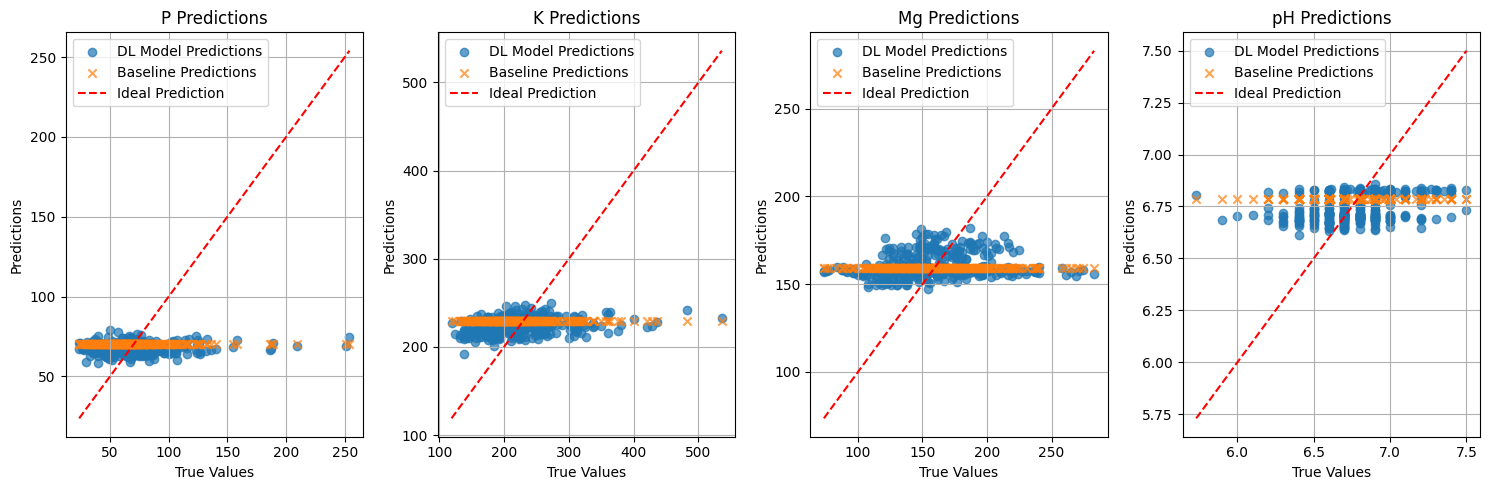

In [ ]:
# Load the best model weights for the deep learning model
#model.load_state_dict(torch.load("best_hyperspectral_model.pth"))

# Evaluate the deep learning model
dl_y_test_pred, dl_y_test_true, dl_model_mse_targets = evaluate_dl_model(model, test_loader, scaler_y, device)

# Evaluate the baseline regressor (using the globally available y_test_true from inverse scaling test_dataset labels)
baseline_y_test_pred, baseline_mse_targets = evaluate_baseline_regressor(baseline_reg_current, X_test_filtered, y_test_true)

# Calculate and print combined results, including plotting
calculate_and_print_results(dl_model_mse_targets, baseline_mse_targets, y_test_true, dl_y_test_pred, baseline_y_test_pred)

In [ ]:
def display_predictions_table(model, test_loader, scaler_y, device):
    """Displays the model's predictions against ground truth values in a tabular form (unscaled)."""
    model.eval()  # Set the model to evaluation mode
    all_predictions_scaled = []
    all_true_values_scaled = []

    with torch.no_grad():
        for X_batch, y_batch_true_scaled in test_loader:
            X_batch = X_batch.to(device)
            preds_batch = model(X_batch)
            all_predictions_scaled.append(preds_batch.cpu().numpy())
            all_true_values_scaled.append(y_batch_true_scaled.cpu().numpy())

    # Concatenate all batches
    y_predictions_scaled = np.vstack(all_predictions_scaled)
    y_true_scaled = np.vstack(all_true_values_scaled)

    # Inverse transform to get original values
    y_predictions_unscaled = scaler_y.inverse_transform(y_predictions_scaled)
    y_true_unscaled = scaler_y.inverse_transform(y_true_scaled)

    # Create a DataFrame for display
    target_names = ["P", "K", "Mg", "pH"]

    # To ensure consistent number of samples, we'll just take a few examples from the test set
    num_samples_to_display = min(10, len(y_predictions_unscaled))

    # Correctly build the dictionary for DataFrame
    data_for_df = {}
    for i, name in enumerate(target_names):
        data_for_df[f'True {name}'] = y_true_unscaled[:num_samples_to_display, i]
        data_for_df[f'Pred {name}'] = y_predictions_unscaled[:num_samples_to_display, i]

    df_display = pd.DataFrame(data_for_df)

    print(f"\nSample of {num_samples_to_display} Predictions vs. True Values (Unscaled):")
    display(df_display)

# Example usage of the function:
display_predictions_table(model, test_loader, scaler_y, device)



Sample of 10 Predictions vs. True Values (Unscaled):


,True P,Pred P,True K,Pred K,True Mg,Pred Mg,True pH,Pred pH
0,64.599998,67.982132,243.0,233.455597,184.000000,152.802826,6.50,6.708163
1,36.099998,67.960861,193.0,223.414108,77.200005,157.848618,5.73,6.806095
2,56.400002,66.243362,213.0,209.766953,154.000000,169.826141,6.70,6.689506
3,46.500000,65.504700,146.0,209.786774,116.000000,150.458572,6.90,6.712736
4,57.599998,65.006332,234.0,234.840286,167.000000,169.029831,6.40,6.614975
5,68.400002,67.094131,230.0,232.114258,220.000000,158.826141,6.80,6.825886
6,35.500000,64.607414,132.0,209.716187,120.000000,151.153870,6.80,6.707272
7,96.199997,64.463448,226.0,217.881088,140.000000,161.048325,6.80,6.711034
8,45.400002,70.396194,209.0,224.207108,143.000000,159.079590,6.80,6.752722
9,123.000000,75.166504,363.0,239.595886,195.000000,155.299789,6.96,6.808602


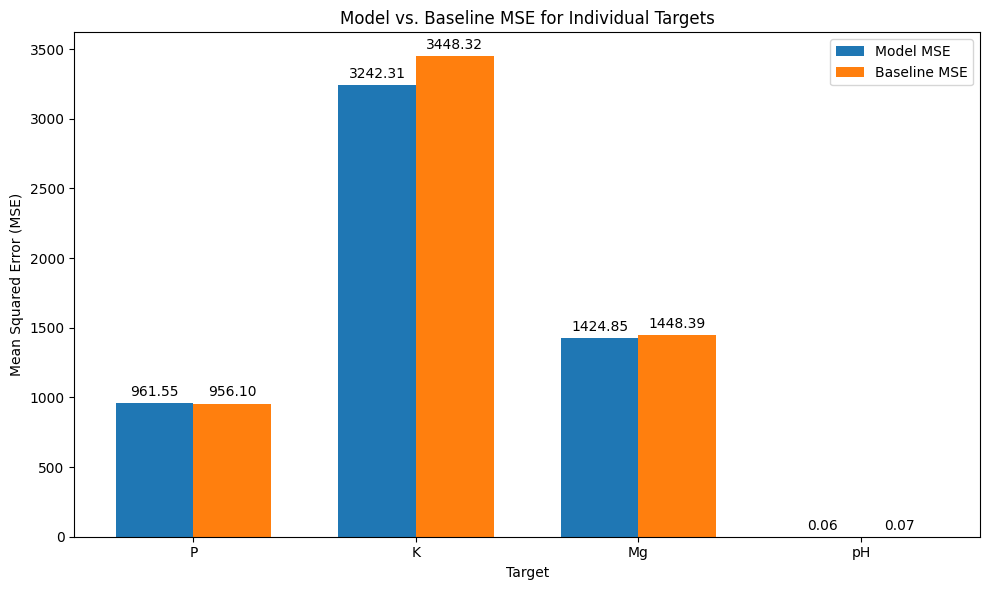

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

target_names = ["P", "K", "Mg", "pH"]

# Get the MSEs from the kernel state
# Assuming model_mse_targets and baseline_mse_targets are available from previous execution
model_mse_targets = np.array(model_mse_targets) # Ensure it's a numpy array for indexing
baseline_mse_targets = np.array(baseline_mse_targets) # Ensure it's a numpy array for indexing

x = np.arange(len(target_names))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, model_mse_targets, width, label='Model MSE')
rects2 = ax.bar(x + width/2, baseline_mse_targets, width, label='Baseline MSE')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Target')
ax.set_ylabel('Mean Squared Error (MSE)')
ax.set_title('Model vs. Baseline MSE for Individual Targets')
ax.set_xticks(x)
ax.set_xticklabels(target_names)
ax.legend()

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()

## Generate submission file

In [ ]:
import gc

del train_dataset
del val_dataset
del test_dataset
del train_loader
del val_loader
del test_loader

gc.collect()

13649

In [ ]:
# import torch
# torch.cuda.empty_cache()

In [ ]:
X_test_submission = load_data("/content/test_data/test")

In [ ]:


test_dataset_submission  = NPZDataset(X_test_submission, augment=False, global_means=global_means, global_stds=global_stds)
test_submission_loader  = DataLoader(test_dataset_submission, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
model.eval() # Set the model to evaluation mode

submission_predictions_scaled = []

with torch.no_grad():
    for X_batch_submission in test_submission_loader:
        # X_batch_submission contains only features, no labels for submission dataset
        X_batch_submission = X_batch_submission.to(next(model.parameters()).device)
        preds_batch = model(X_batch_submission)
        submission_predictions_scaled.append(preds_batch.cpu().numpy())

y_submission_scaled_pred = np.vstack(submission_predictions_scaled)

# Inverse transform predictions to get original values
y_submission_pred = scaler_y.inverse_transform(y_submission_scaled_pred)

# Create submission DataFrame
submission = pd.DataFrame(data=y_submission_pred, columns=["P", "K", "Mg", "pH"])

# Save to CSV
submission.to_csv("submission.csv", index_label="sample_index")
print("Submission file 'submission.csv' created successfully!")

Submission file 'submission.csv' created successfully!
